# XGBoost forest structure — cross-dataset comparison

Loads `processed_capability_results/xgb_capability_comparison.csv` produced by `xgb_capability_comparison.py` and plots **structure metrics** (leaves, depth, split-feature entropy) and **accuracy** across **magic**, **raisin**, and **bidding**.

**Convention:** Lines show the **mean over CV folds**; shaded bands are **±1 std** (when multiple folds exist).


In [4]:
import os

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")

# Notebook lives in analysis/; CSV is written next to processed_capability_results
NOTEBOOK_DIR = os.getcwd()
if os.path.basename(NOTEBOOK_DIR) == "analysis":
    CSV_PATH = os.path.join(NOTEBOOK_DIR, "..", "processed_capability_results", "xgb_capability_comparison.csv")
else:
    CSV_PATH = os.path.join("processed_capability_results", "xgb_capability_comparison.csv")

CSV_PATH = os.path.normpath(os.path.abspath(CSV_PATH))
print("CSV:", CSV_PATH)
if not os.path.isfile(CSV_PATH):
    raise FileNotFoundError(
        f"Missing {CSV_PATH}. Run from project root: python xgb_capability_comparison.py --home-dir ."
    )

df = pd.read_csv(CSV_PATH)
print("rows:", len(df), "| columns:", list(df.columns))
df.head()


CSV: /Users/beliz/Desktop/thesis_project/SagiXGBoostTreeApproximator/processed_capability_results/xgb_capability_comparison.csv
rows: 1 | columns: ['dataset', 'fold', 'trial_id', 'base_seed', 'random_state', 'n_estimators', 'max_depth', 'n_features', 'n_train_samples', 'fit_time_sec', 'train_acc', 'val_acc', 'test_acc', 'n_trees', 'total_leaves', 'mean_leaves_per_tree', 'std_leaves_per_tree', 'max_leaves_single_tree', 'mean_max_depth_per_tree', 'max_depth_any_tree', 'n_distinct_split_features', 'split_feature_entropy_bits']


,dataset,fold,trial_id,base_seed,random_state,n_estimators,max_depth,n_features,n_train_samples,fit_time_sec,...,test_acc,n_trees,total_leaves,mean_leaves_per_tree,std_leaves_per_tree,max_leaves_single_tree,mean_max_depth_per_tree,max_depth_any_tree,n_distinct_split_features,split_feature_entropy_bits
0,raisin,0,0,42,42,10,3,7,630,0.027593,...,0.844444,10,78,7.8,0.4,8,3.0,3,7,2.436656


In [5]:
# Aggregate: mean ± std over folds for each (dataset, n_estimators, max_depth)
agg_cols = [
    "total_leaves",
    "mean_leaves_per_tree",
    "max_leaves_single_tree",
    "mean_max_depth_per_tree",
    "max_depth_any_tree",
    "n_distinct_split_features",
    "split_feature_entropy_bits",
    "fit_time_sec",
    "train_acc",
    "val_acc",
    "test_acc",
]

agg = df.groupby(["dataset", "n_estimators", "max_depth"])[agg_cols].agg(["mean", "std"])
agg.columns = ["_".join(col).strip() for col in agg.columns.values]
agg = agg.reset_index()
agg.head()


,dataset,n_estimators,max_depth,total_leaves_mean,total_leaves_std,mean_leaves_per_tree_mean,mean_leaves_per_tree_std,max_leaves_single_tree_mean,max_leaves_single_tree_std,mean_max_depth_per_tree_mean,...,split_feature_entropy_bits_mean,split_feature_entropy_bits_std,fit_time_sec_mean,fit_time_sec_std,train_acc_mean,train_acc_std,val_acc_mean,val_acc_std,test_acc_mean,test_acc_std
0,raisin,10,3,78.0,NaN,7.8,NaN,8.0,NaN,3.0,...,2.436656,NaN,0.027593,NaN,0.9,NaN,0.833333,NaN,0.844444,NaN


In [6]:
# --- Line plots: metrics vs n_estimators, one panel per max_depth, hue = dataset ---

datasets = sorted(agg["dataset"].unique())

def lineplot_by_depth(
    y_mean_col,
    y_std_col=None,
    *,
    title_y,
    ylabel,
    sharey=False,
):
    depths = sorted(agg["max_depth"].unique())
    fig, axes = plt.subplots(
        1,
        len(depths),
        figsize=(5 * len(depths), 4.2),
        sharey=sharey,
        squeeze=False,
    )
    axes = axes.flatten()
    palette = sns.color_palette("Set1", n_colors=len(datasets))
    cmap = dict(zip(datasets, palette))

    for ax, d in zip(axes, depths):
        sub = agg[agg["max_depth"] == d]
        for ds in datasets:
            s = sub[sub["dataset"] == ds].sort_values("n_estimators")
            x = s["n_estimators"]
            y = s[y_mean_col]
            ax.plot(x, y, marker="o", label=ds, color=cmap[ds], linewidth=2)
            if y_std_col and y_std_col in s.columns:
                err = s[y_std_col].fillna(0)
                ax.fill_between(x, y - err, y + err, color=cmap[ds], alpha=0.15)
        ax.set_title(f"max_depth = {d}")
        ax.set_xlabel("n_estimators")
        ax.set_ylabel(ylabel)
        ax.legend(title="dataset")
    fig.suptitle(title_y, fontsize=13, fontweight="bold", y=1.02)
    plt.tight_layout()
    plt.show()


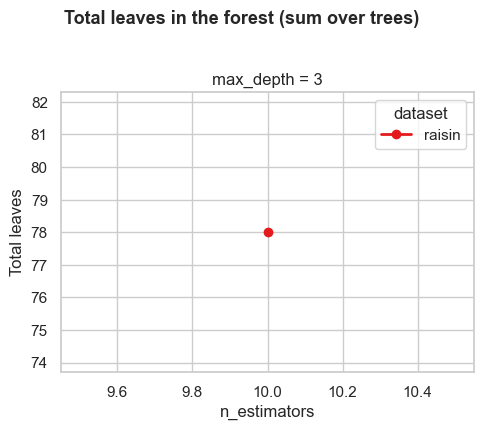

In [7]:
lineplot_by_depth(
    "total_leaves_mean",
    "total_leaves_std",
    title_y="Total leaves in the forest (sum over trees)",
    ylabel="Total leaves",
)


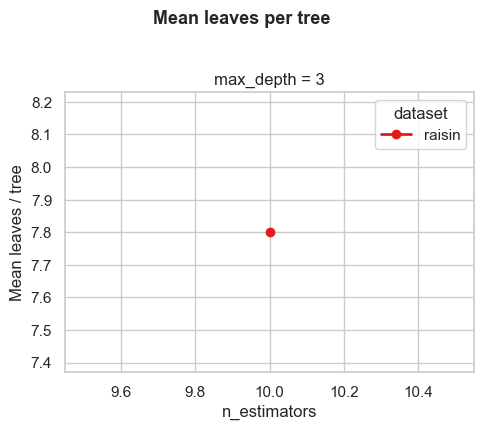

In [8]:
lineplot_by_depth(
    "mean_leaves_per_tree_mean",
    "mean_leaves_per_tree_std",
    title_y="Mean leaves per tree",
    ylabel="Mean leaves / tree",
)


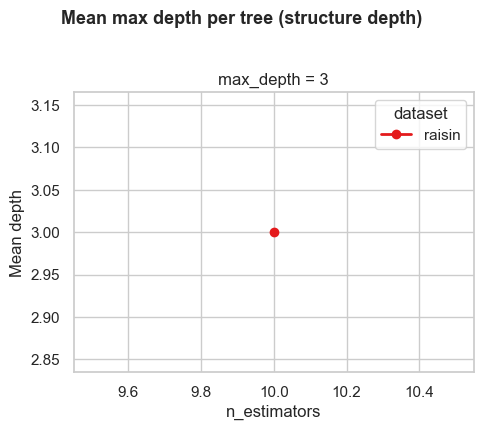

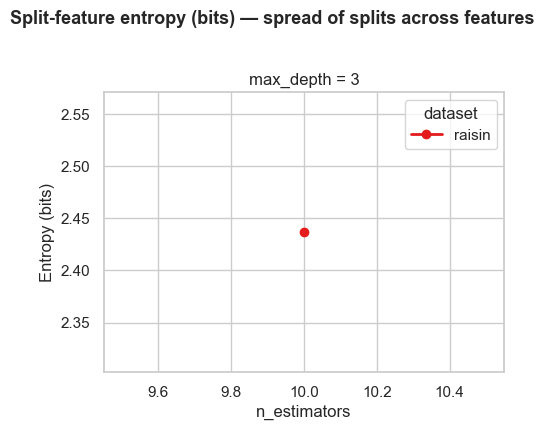

In [9]:
lineplot_by_depth(
    "mean_max_depth_per_tree_mean",
    "mean_max_depth_per_tree_std",
    title_y="Mean max depth per tree (structure depth)",
    ylabel="Mean depth",
)
lineplot_by_depth(
    "split_feature_entropy_bits_mean",
    "split_feature_entropy_bits_std",
    title_y="Split-feature entropy (bits) — spread of splits across features",
    ylabel="Entropy (bits)",
)


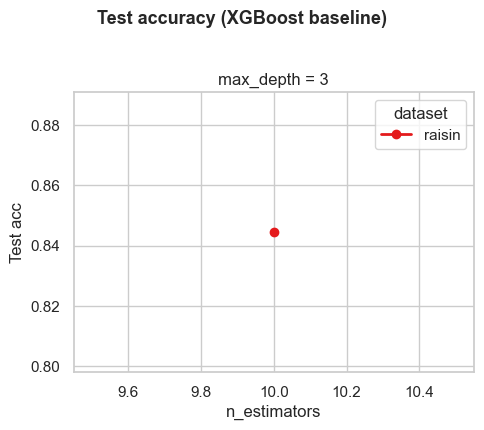

In [10]:
lineplot_by_depth(
    "test_acc_mean",
    "test_acc_std",
    title_y="Test accuracy (XGBoost baseline)",
    ylabel="Test acc",
    sharey=True,
)


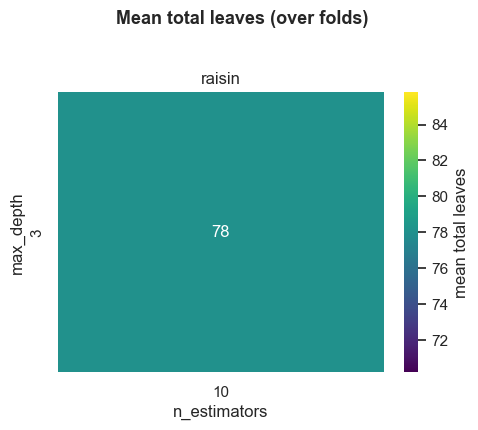

In [11]:
# --- Heatmaps: mean total_leaves over folds, one panel per dataset ---

pivot_tables = {}
for ds in datasets:
    p = (
        agg[agg["dataset"] == ds]
        .pivot(index="max_depth", columns="n_estimators", values="total_leaves_mean")
        .sort_index(axis=0)
        .sort_index(axis=1)
    )
    pivot_tables[ds] = p

fig, axes = plt.subplots(1, len(datasets), figsize=(5 * len(datasets), 4.2))
if len(datasets) == 1:
    axes = [axes]
for ax, ds in zip(axes, datasets):
    sns.heatmap(
        pivot_tables[ds],
        ax=ax,
        annot=True,
        fmt=".0f",
        cmap="viridis",
        cbar_kws={"label": "mean total leaves"},
    )
    ax.set_title(ds)
    ax.set_xlabel("n_estimators")
    ax.set_ylabel("max_depth")
fig.suptitle("Mean total leaves (over folds)", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


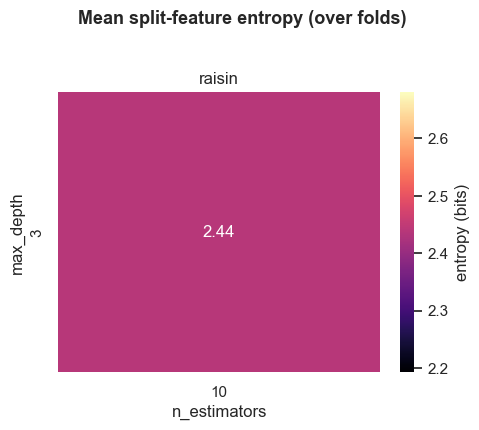

In [12]:
# --- Heatmaps: mean split_feature_entropy_bits ---

fig, axes = plt.subplots(1, len(datasets), figsize=(5 * len(datasets), 4.2))
if len(datasets) == 1:
    axes = [axes]
for ax, ds in zip(axes, datasets):
    p = (
        agg[agg["dataset"] == ds]
        .pivot(index="max_depth", columns="n_estimators", values="split_feature_entropy_bits_mean")
        .sort_index(axis=0)
        .sort_index(axis=1)
    )
    sns.heatmap(
        p,
        ax=ax,
        annot=True,
        fmt=".2f",
        cmap="magma",
        cbar_kws={"label": "entropy (bits)"},
    )
    ax.set_title(ds)
    ax.set_xlabel("n_estimators")
    ax.set_ylabel("max_depth")
fig.suptitle("Mean split-feature entropy (over folds)", fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.show()


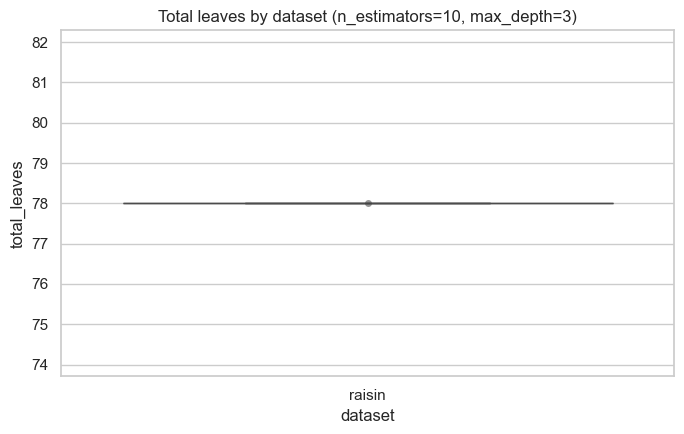

In [13]:
# --- Optional: per-fold strip — distribution of total_leaves for one (n, d) ---

pick_n, pick_d = 60, 4
sub = df[(df["n_estimators"] == pick_n) & (df["max_depth"] == pick_d)]
if len(sub) < 2:
    pick_n = int(df["n_estimators"].median())
    pick_d = int(df["max_depth"].median())
    sub = df[(df["n_estimators"] == pick_n) & (df["max_depth"] == pick_d)]

plt.figure(figsize=(7, 4.5))
sns.boxplot(data=sub, x="dataset", y="total_leaves")
sns.stripplot(data=sub, x="dataset", y="total_leaves", color="0.25", alpha=0.55, jitter=0.12)
plt.title(f"Total leaves by dataset (n_estimators={pick_n}, max_depth={pick_d})")
plt.tight_layout()
plt.show()
